# Student Depression Model

Este dataset recopila información, de diferentes universidades, de personas (en su mayoría estudiantes) y diferentes factores de su vida y su salud mental. El dataset cuenta con 27901 entradas (personas) y 18 columnas de características de ellas. En la variable que dirigiremos nuestros esfuerzos es la binaria "Depression". Esta indica si la persona sufre de depresión (1 si sí, 0 si no). Buscaremos producir un modelo predictivo para la depresión, tomando en cuenta las limitaciones que este puede tener por razones obvias.

El dataset es tomado de Kaggle, publicado por Adil Shamim.

In [35]:
import pandas as pd
import numpy as np
from sklearn.tree import plot_tree
from sklearn.model_selection  import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize, StandardScaler
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [63]:
df = pd.read_csv("datasets/student_depression_dataset.csv")
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

## Preparación de Datos

Siempre es importante realizar una preparación de datos, sin importar cuan "perfectos" estén. Incluso si no poseen errores, es necesario adaptar la base de datos al enfoque de nuestro análisis y transformar s¿ciertas variables.

Como nuestro propósito es predecir la variable depresión, removeremos el id que es irrelevante. Del mismo modo, la ciudad cuenta con demasiadas diferentes que dificultarán el análisis, además que no suscitan a acciones concretas (a menos que se concentre mucho en una sola ciudad) y generará más ruido de lo que ayudará. Remover estos también mantienen confidencialidad.

In [64]:
df = df.drop(columns=['id', 'City'])
print(len(df), "entradas")
df.head()

27901 entradas


,Gender,Age,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


Solo nos interesan los estudiantes en este caso, por lo que nos quedaremos con un dataset compuesto solamente de estudiantes.

In [65]:
students = df[df['Profession'] == 'Student']
students['Profession'].unique()
print("El nuevo dataset contiene", len(students), "etudiantes")

El nuevo dataset contiene 27870 etudiantes


In [66]:
students.info()
len(students)

<class 'pandas.DataFrame'>
Index: 27870 entries, 0 to 27900
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27870 non-null  str    
 1   Age                                    27870 non-null  float64
 2   Profession                             27870 non-null  str    
 3   Academic Pressure                      27870 non-null  float64
 4   Work Pressure                          27870 non-null  float64
 5   CGPA                                   27870 non-null  float64
 6   Study Satisfaction                     27870 non-null  float64
 7   Job Satisfaction                       27870 non-null  float64
 8   Sleep Duration                         27870 non-null  str    
 9   Dietary Habits                         27870 non-null  str    
 10  Degree                                 27870 non-null  str    
 11  Have you ever had 

27870

Como se había mencionado, en su mayoría son estudiantes. Para continuar, debemos notar si los datos muestran algún desbalanceo de clases. La crucial a comparar es de quienes tienen y no tienen depresión. También, analizaremos si hay desbalance entre hombres y mujeres estudiadas.

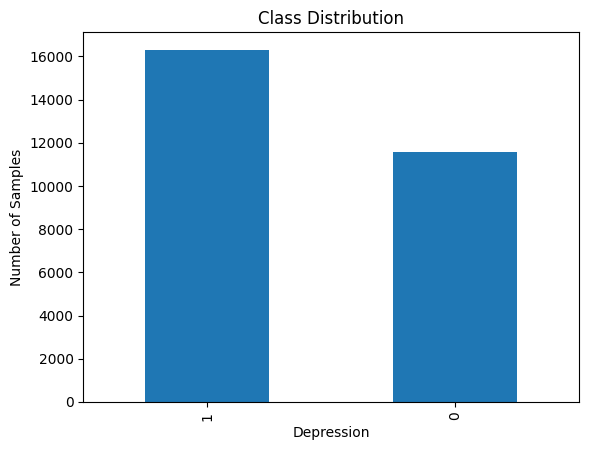

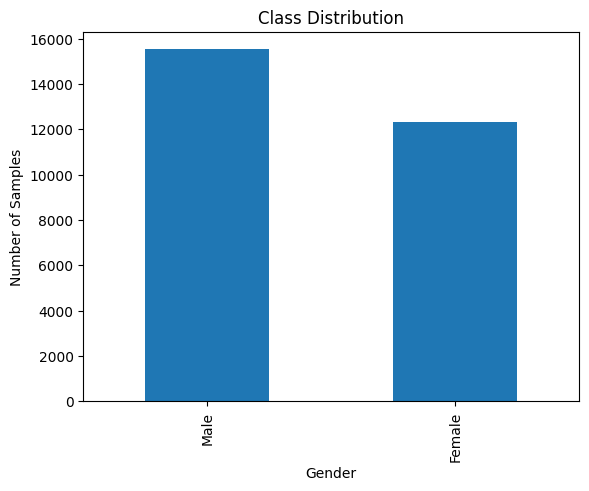

In [67]:
depression_frequency = students['Depression'].value_counts()

depression_frequency.plot(kind='bar')

plt.xlabel("Depression")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

gender_frequency = students['Gender'].value_counts()

gender_frequency.plot(kind='bar')

plt.xlabel("Gender")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

Ambos grupos se consideran balanceados (en términos de Data Science y problemas de baja representación), por lo que no es necesario rebalanceo de las clases. Sin embargo, al sí tener diferencia proporcional (aunque mínima), se deberá hacer test y tran splits estratificados de depresión y por género, para sí reflejar la disparidad de estos datos. Para ello, generaremos una nueva columna.

In [68]:
students['estratificacion'] = students['Gender'].astype(str) + "_" + df['Depression'].astype(str)

X = students.drop(columns = ['Depression', 'estratificacion'])
y = students['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=students['estratificacion']
)

## Support Vector Machine

Se utilizará este modelo por la naturaleza binaria de la variable dependiente.

In [55]:
svm = SVC(probability=True, random_state = 42)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2,3,4],
    'gamma': ['auto','scale']
}
grid_search = GridSearchCV(estimator = svm,  param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)

y_pred = best_model.predict(X_test)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Depression in Students (SVM)")
plt.show()

# Classification report
report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report:")
print(report)

y_score = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw = 2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color = 'gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for "{positive_class}" vs Rest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Fitting 5 folds for each of 72 candidates, totalling 360 fits


ValueError: 
All the 360 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\jesus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jesus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\jesus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py", line 205, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
   

# Random Forest

In [ ]:
# Hyperparameter grid for random forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3,5,7,None],
    'min_samples_split': [2,4,6],
    'min_samples_leaf': [1,2,4],
    'max_features': [None, 'sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator = rf,  param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train_balanced, y_train_balanced)

best_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)

y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification report
report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report:")
print(report)

#ROC Curve - One vs. rest (Multiclass)
y_test_binarized = label_binarize(y_test, classes = best_model.classes_)
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8,6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label], tpr[class_label], lw=2, label=f'{class_label} (AUC = {roc_auc[class_label]:.2f})')
plt.plot([0,1], [0,1], color = 'gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for each Class (OvR strategy)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()